In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys, os, re
from pathlib import Path
from typing import Optional
sys.path.append('../')

from src import *

seed = 42
np.random.seed(seed)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
df = pd.read_parquet("../data/all_raman_spectra.parquet")

In [4]:
df.head()

,X,Y,Wave,Intensity,label,group,center,brain,place
0,-511.945953,-16787.546875,2002.376953,13577.683594,exo,2b,1500,striatum_right,2_4
1,-511.945953,-16787.546875,2001.416992,13663.965820,exo,2b,1500,striatum_right,2_4
2,-511.945953,-16787.546875,2000.457031,13875.706055,exo,2b,1500,striatum_right,2_4
3,-511.945953,-16787.546875,1999.496094,13786.798828,exo,2b,1500,striatum_right,2_4
4,-511.945953,-16787.546875,1998.536133,13700.540039,exo,2b,1500,striatum_right,2_4


✅ Загружена карта 35 × 15 точек


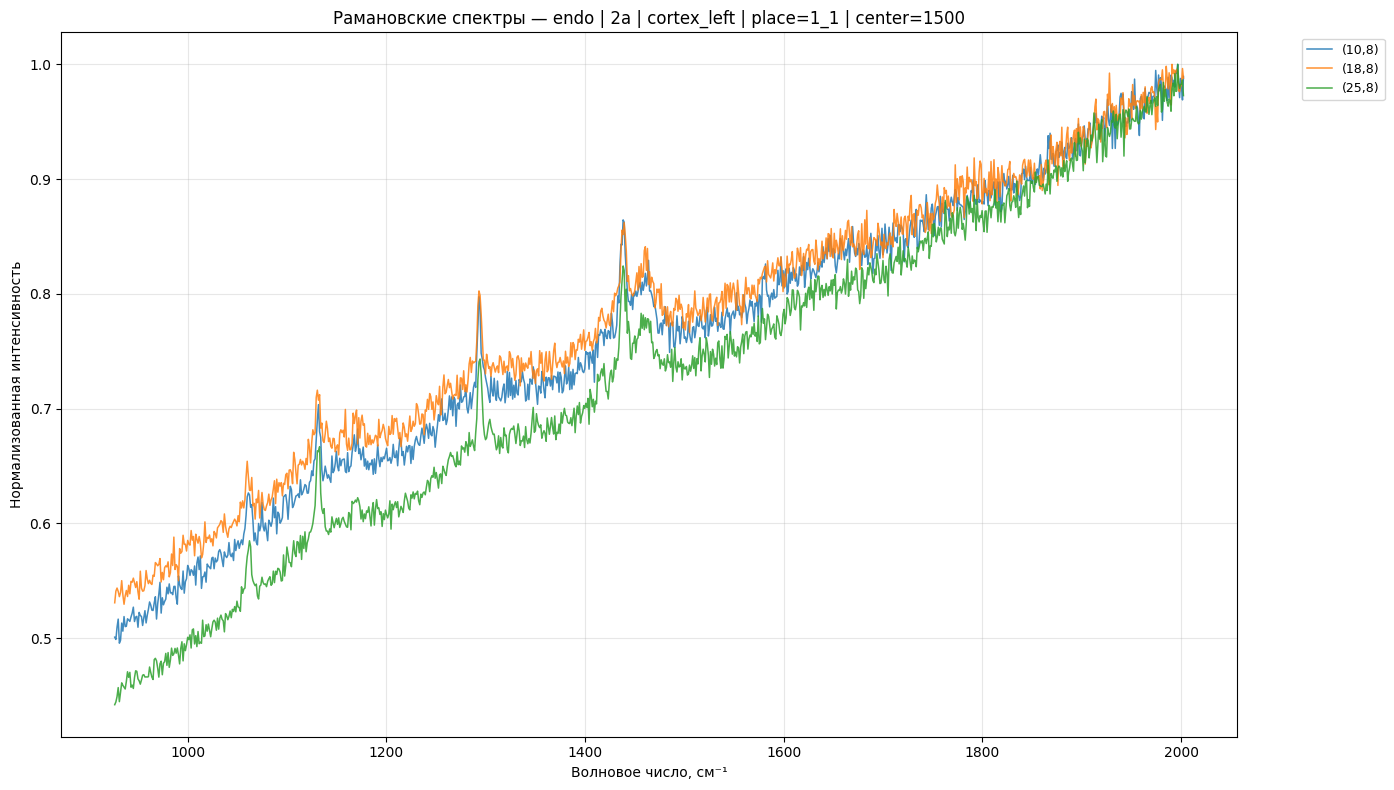

In [5]:
# 1. Из большого DataFrame — конкретные точки
plot_raman_spectra(
    df=df,
    label='endo',
    group='2a',
    center='1500',
    brain='cortex_left',
    place='1_1',                    # ← обязательно для одной карты
    points=[(10, 8), (18, 8), (25, 8)],
    normalize=True,
    wave_range=(0, 1000000)
)

✅ Загружена карта 35 × 15 точек


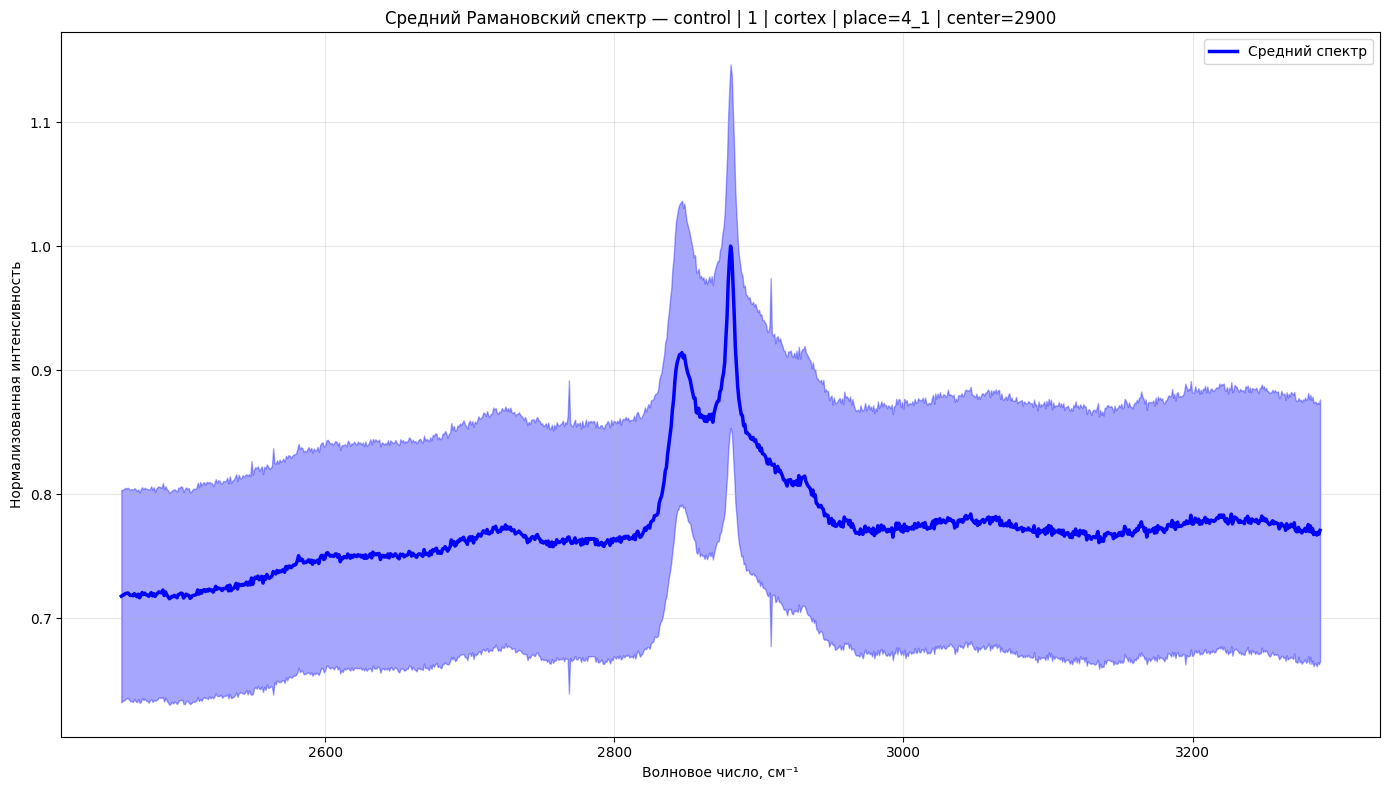

✅ Загружена карта 35 × 15 точек


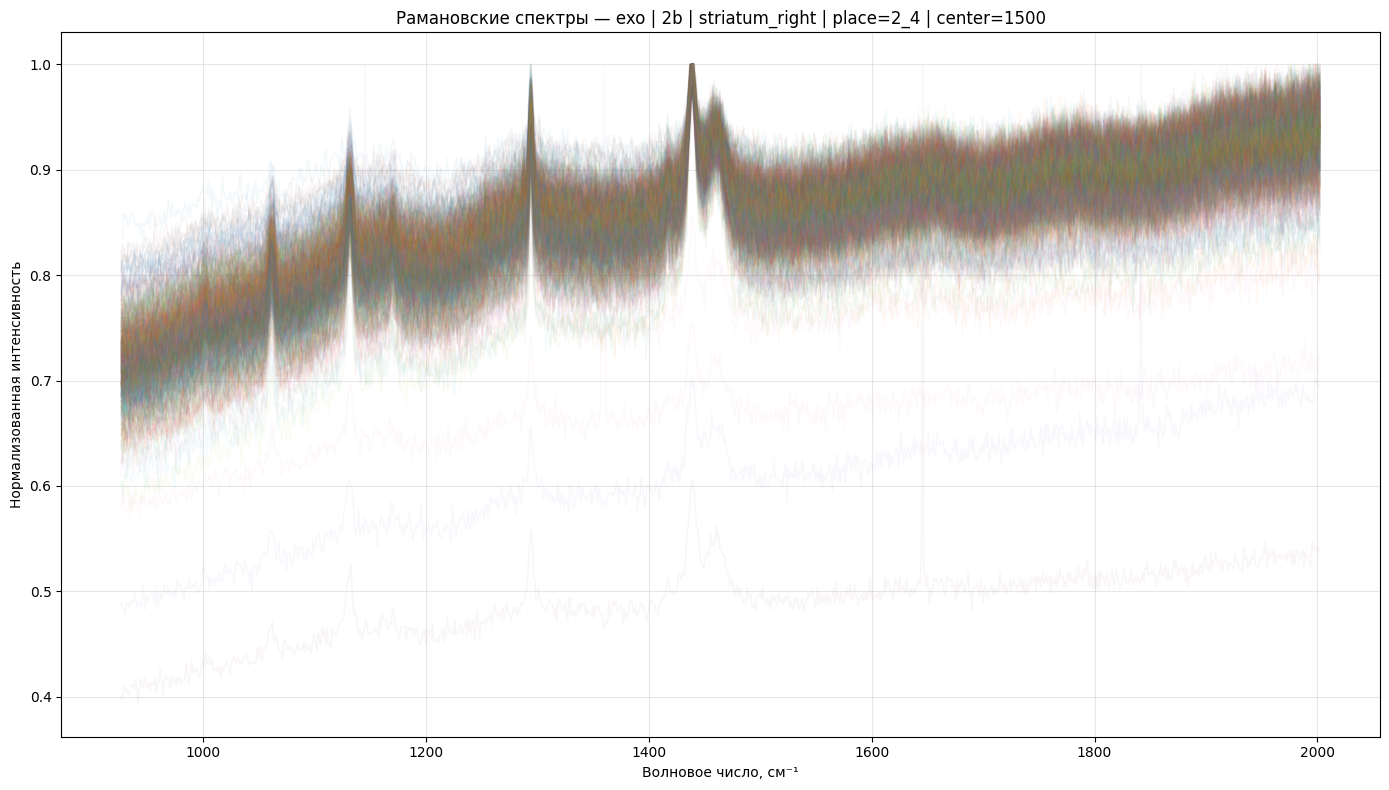

In [13]:
# 2. Средний спектр всей карты (с разбросом)
plot_raman_spectra(
    df=df,
    label='control',
    group='1',
    center='2900',
    brain='cortex',
    place='4_1',
    plot_average=True,
    normalize=True
)

# 4. Все спектры карты (плотный график)
plot_raman_spectra(
    df=df,
    label='exo',
    group='2b',
    center='1500',
    brain='striatum_right',
    place='2_4',
    alpha=0.05
)

In [ ]:
# 2. Примеры:

# Из файла
plot_raman_spectra("path/to/file.txt", points=[(5, 3), (18, 8), (30, 12)])

# Из большого df (конкретные точки)
plot_raman_spectra(df, label='endo', group='2a', center=1500, brain='cortex_left',
                   points=[(10, 5), (25, 10)])

# Все спектры карты (как вы просили)
plot_raman_spectra(df, label='control', group='1', center=2900, brain='cortex')

# С нормализацией (очень полезно для сравнения форм пиков)
plot_raman_spectra(df, label='exo', group='2b', center=1500, brain='striatum_right',
                   points=[(15, 8)], normalize=True)